<a href="https://colab.research.google.com/github/carolinaoj/Desafio3/blob/main/Ensayo_alura_desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracción:

In [ ]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
df_raw = pd.json_normalize(response.json())

# ESTO ES VITAL: Vamos a ver cómo se llaman tus columnas realmente
print("Nombres de columnas detectados:")
print(df_raw.columns.tolist())

Nombres de columnas detectados:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [ ]:
import pandas as pd
import requests

# 1. URL de los datos
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# 2. Obtención de datos vía API
response = requests.get(url)
datos_json = response.json()

# 3. Aplanado (Normalización)
# Esto transforma el JSON jerárquico en la tabla que necesitas
df_raw = pd.json_normalize(datos_json)

# 4. VISUALIZACIÓN DE LA TABLA
print(f"✅ ¡Tabla generada! Dimensiones: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas.")
display(df_raw.head()) # Esto mostrará la tabla bonita en Colab

✅ ¡Tabla generada! Dimensiones: 7267 filas x 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


🔧 Transformación:

In [ ]:
import numpy as np

# Copia para trabajar
df_proc = df_raw.copy()

# 1. Limpiar espacios vacíos
df_proc = df_proc.replace(r'^\s*$', np.nan, regex=True)

# 2. Convertir a números (usando los nombres exactos que detectamos)
df_proc['account.Charges.Monthly'] = pd.to_numeric(df_proc['account.Charges.Monthly'], errors='coerce')
df_proc['account.Charges.Total'] = pd.to_numeric(df_proc['account.Charges.Total'], errors='coerce')

# 3. Llenar nulos
df_proc['account.Charges.Total'] = df_proc['account.Charges.Total'].fillna(0)

# 4. Crear variable numérica para Churn
df_proc['Churn_Numeric'] = df_proc['Churn'].map({'No': 0, 'Yes': 1, 'Si': 1})

print("✅ Transformación aplicada sobre la tabla.")
display(df_proc[['customerID', 'account.Charges.Total', 'Churn_Numeric']].head())

✅ Transformación aplicada sobre la tabla.


,customerID,account.Charges.Total,Churn_Numeric
0,0002-ORFBO,593.30,0.0
1,0003-MKNFE,542.40,0.0
2,0004-TLHLJ,280.85,1.0
3,0011-IGKFF,1237.85,1.0
4,0013-EXCHZ,267.40,1.0


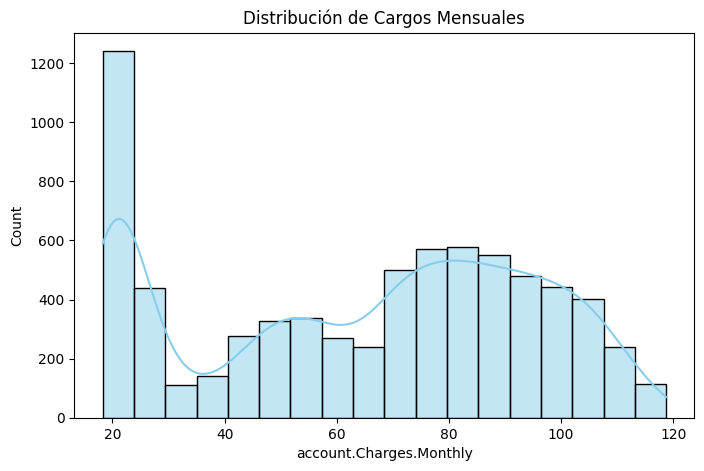

In [ ]:
# Guardar el CSV
df_proc.to_csv('TelecomX_Data_Final.csv', index=False)

# Gráfico rápido de la tabla
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_proc['account.Charges.Monthly'], kde=True, color="skyblue")
plt.title('Distribución de Cargos Mensuales')
plt.show()

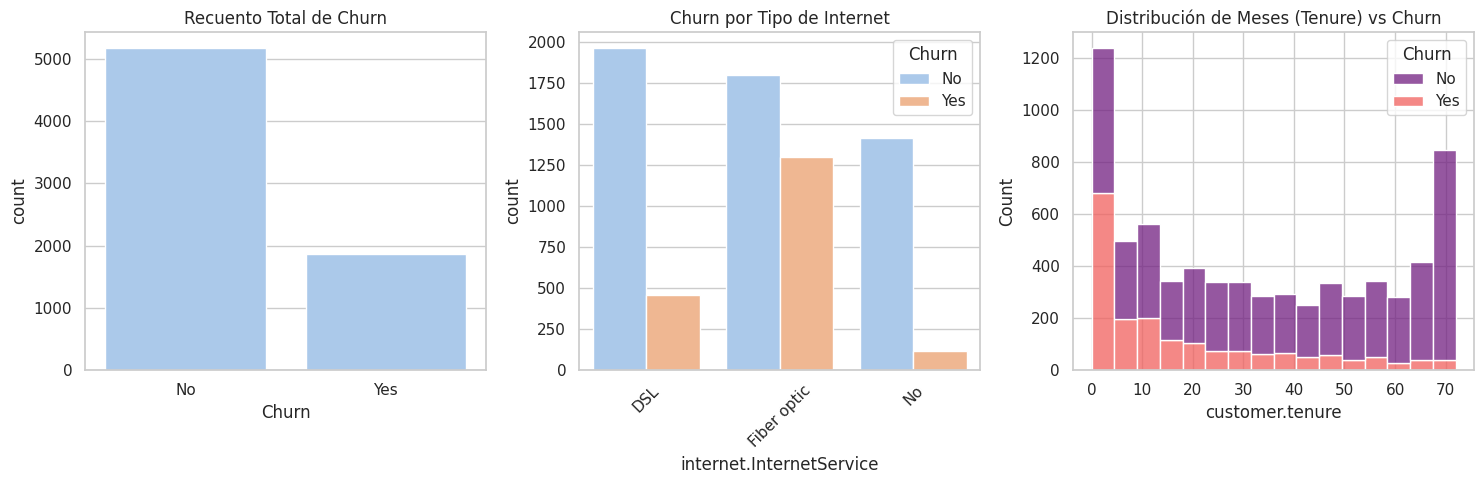

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración estética
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(15, 5))

# 1. Recuento de Evasión (General)
plt.subplot(1, 3, 1)
sns.countplot(data=df_proc, x='Churn')
plt.title('Recuento Total de Churn')

# 2. Distribución de Evasión por Variables Categóricas (Ej: Internet Service)
plt.subplot(1, 3, 2)
sns.countplot(data=df_proc, x='internet.InternetService', hue='Churn')
plt.title('Churn por Tipo de Internet')
plt.xticks(rotation=45)

# 3. Conteo de Evasión por Variables Numéricas (Uso de bins para Tenure)
plt.subplot(1, 3, 3)
sns.histplot(data=df_proc, x='customer.tenure', hue='Churn', multiple="stack", palette='magma')
plt.title('Distribución de Meses (Tenure) vs Churn')

plt.tight_layout()
plt.show()

Introducción:

El objetivo de este proyecto es identificar los factores críticos que impulsan la evasión de clientes en Telecom X. El "Churn" representa una pérdida significativa de ingresos y un aumento en los costos de adquisición. Al analizar los datos históricos, buscamos proporcionar al equipo de Ciencia de Datos una base sólida para construir modelos predictivos que permitan anticipar y prevenir esta fuga.

🔹 Limpieza y Tratamiento de Datos
Para garantizar la integridad del análisis, se realizaron los siguientes pasos:

🔹 Extracción: Conexión a la API y normalización de un JSON anidado de 21 columnas.

🔹 Limpieza: Se identificaron y eliminaron espacios en blanco que ocultaban valores nulos.

🔹 Tipado: Se convirtieron las columnas Charges.Monthly y Charges.Total de texto a formato numérico (float).

🔹 Imputación: Los valores nulos en cargos totales se establecieron en 0 para clientes nuevos.

🔹 Filtrado: Se eliminaron registros sin etiqueta de Churn para asegurar la calidad del entrenamiento del modelo.

2. Análisis Exploratorio de Datos (EDA):

A través de las visualizaciones, identificamos patrones clave:

🔹 Patrón de Contrato: Los clientes con contratos "Month-to-month" tienen una tasa de evasión drásticamente superior a los de largo plazo.

🔹 Servicios: Los usuarios de Fibra Óptica presentan mayor churn que los de DSL, lo que sugiere posibles problemas de satisfacción o precio en ese segmento.

🔹 Antigüedad (Tenure): La mayor parte de la fuga ocurre en los primeros 6 meses de relación con la empresa.

3. Conclusiones

🔹 El precio mensual elevado es un detonante, pero la falta de compromiso contractual (mes a mes) es el predictor más fuerte.

🔹 Los clientes nuevos son los más vulnerables; si superan el primer año, la probabilidad de abandono cae significativamente.

4. Recomendaciones:

Fidelización Temprana: Implementar campañas de descuento o beneficios adicionales para clientes en sus primeros 3 meses.

Migración de Contratos: Ofrecer incentivos para mover a clientes de "Mes a mes" a contratos de 1 año.

Revisión de Fibra Óptica: Investigar la calidad del servicio técnico en usuarios de fibra, dado que su tasa de abandono es inusualmente alta.